# DPN Classification from Plantar Thermograms

This notebook trains and evaluates models to classify diabetic peripheral neuropathy (DPN) from plantar thermogram images.

## Contents
1. Setup and Data Loading
2. Data Exploration
3. Classical ML Models (Random Forest, SVM, etc.)
4. Deep Learning Models (CNN)
5. Model Comparison and Evaluation

## 1. Setup and Imports

In [1]:
# Standard imports
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import our modules
from models.data_loader import (
    create_data_loaders,
    load_data_for_sklearn,
    ThermogramDataset
)
from models.preprocessing import (
    extract_all_features,
    apply_pca,
    select_best_features
)
from models.model import (
    ThermogramCNN,
    LightweightCNN,
    ThermogramResNet,
    create_random_forest,
    create_svm,
    create_gradient_boosting,
    create_mlp,
    get_model
)
from models.trainer import (
    CNNTrainer,
    SklearnTrainer,
    cross_validate_sklearn,
    print_metrics
)

# PyTorch
import torch
import torch.nn as nn

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, RocCurveDisplay
)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cpu
CUDA available: False


In [2]:
# Configuration
DATA_DIR = "../data"
CHECKPOINT_DIR = "../checkpoints"
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.1

# Create directories
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

# Check if data directory exists
if Path(DATA_DIR).exists():
    print(f"Data directory found: {DATA_DIR}")
    print(f"  Control Group: {len(list((Path(DATA_DIR) / 'Control Group').iterdir()))} subjects")
    print(f"  DM Group: {len(list((Path(DATA_DIR) / 'DM Group').iterdir()))} subjects")
else:
    print(f"ERROR: Data directory not found at {DATA_DIR}")

Data directory found: ../data
  Control Group: 45 subjects
  DM Group: 122 subjects


## 2. Data Exploration

Control sample: CG001_M
DM sample: DM001_M


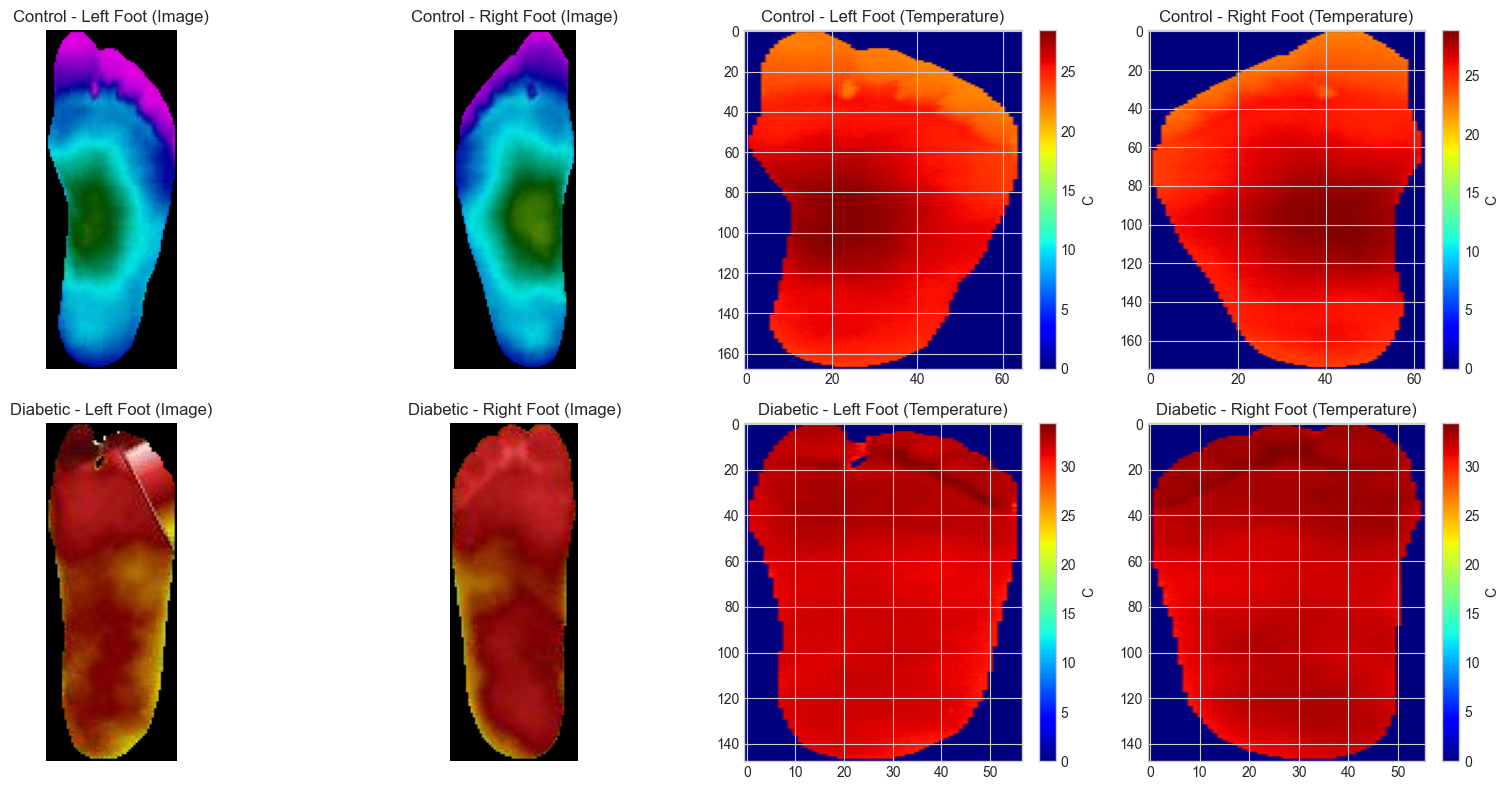


Temperature matrix shape: (148, 57)
Temperature range: 0.00C to 34.46C


In [3]:
# Load a sample image and temperature matrix
from PIL import Image

# Sample from each group
control_sample = list((Path(DATA_DIR) / 'Control Group').iterdir())[0]
dm_sample = list((Path(DATA_DIR) / 'DM Group').iterdir())[0]

print(f"Control sample: {control_sample.name}")
print(f"DM sample: {dm_sample.name}")

# Load and display
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, (sample_dir, label) in enumerate([(control_sample, 'Control'), (dm_sample, 'Diabetic')]):
    subject_id = sample_dir.name
    
    # Left foot image
    left_img = Image.open(sample_dir / f"{subject_id}_L.png")
    axes[idx, 0].imshow(left_img)
    axes[idx, 0].set_title(f"{label} - Left Foot (Image)")
    axes[idx, 0].axis('off')
    
    # Right foot image
    right_img = Image.open(sample_dir / f"{subject_id}_R.png")
    axes[idx, 1].imshow(right_img)
    axes[idx, 1].set_title(f"{label} - Right Foot (Image)")
    axes[idx, 1].axis('off')
    
    # Left temperature matrix
    left_temp = pd.read_csv(sample_dir / f"{subject_id}_L.csv", header=None).values
    im = axes[idx, 2].imshow(left_temp, cmap='jet', aspect='auto')
    axes[idx, 2].set_title(f"{label} - Left Foot (Temperature)")
    plt.colorbar(im, ax=axes[idx, 2], label='C')
    
    # Right temperature matrix
    right_temp = pd.read_csv(sample_dir / f"{subject_id}_R.csv", header=None).values
    im = axes[idx, 3].imshow(right_temp, cmap='jet', aspect='auto')
    axes[idx, 3].set_title(f"{label} - Right Foot (Temperature)")
    plt.colorbar(im, ax=axes[idx, 3], label='C')

plt.tight_layout()
plt.savefig('../checkpoints/sample_data_visualization.png', dpi=150)
plt.show()

print(f"\nTemperature matrix shape: {left_temp.shape}")
print(f"Temperature range: {left_temp.min():.2f}C to {left_temp.max():.2f}C")

C:\Users\Jamel\AppData\Local\Temp\ipykernel_30552\1668331647.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([control_temps, dm_temps], labels=['Control', 'Diabetic'])


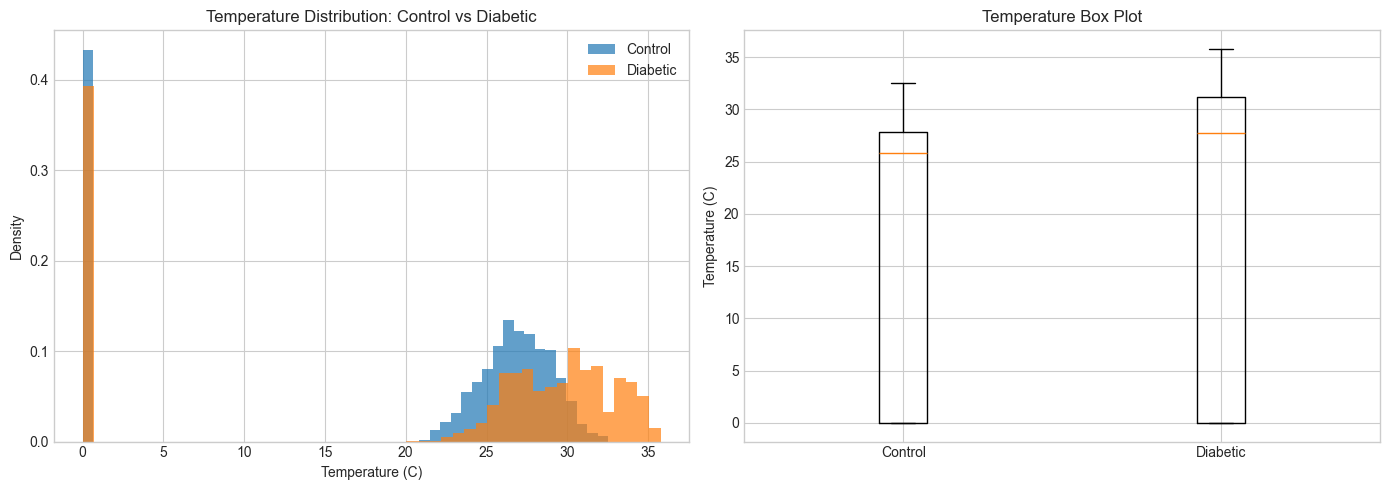

Control mean temp: 19.31C
Diabetic mean temp: 21.41C


In [4]:
# Temperature distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect temperature data from multiple samples
control_temps = []
dm_temps = []

for sample_dir in list((Path(DATA_DIR) / 'Control Group').iterdir())[:10]:
    if sample_dir.is_dir():
        subject_id = sample_dir.name
        temp = pd.read_csv(sample_dir / f"{subject_id}_L.csv", header=None).values
        control_temps.extend(temp.flatten())

for sample_dir in list((Path(DATA_DIR) / 'DM Group').iterdir())[:10]:
    if sample_dir.is_dir():
        subject_id = sample_dir.name
        temp = pd.read_csv(sample_dir / f"{subject_id}_L.csv", header=None).values
        dm_temps.extend(temp.flatten())

# Histogram
axes[0].hist(control_temps, bins=50, alpha=0.7, label='Control', density=True)
axes[0].hist(dm_temps, bins=50, alpha=0.7, label='Diabetic', density=True)
axes[0].set_xlabel('Temperature (C)')
axes[0].set_ylabel('Density')
axes[0].set_title('Temperature Distribution: Control vs Diabetic')
axes[0].legend()

# Box plot
axes[1].boxplot([control_temps, dm_temps], labels=['Control', 'Diabetic'])
axes[1].set_ylabel('Temperature (C)')
axes[1].set_title('Temperature Box Plot')

plt.tight_layout()
plt.savefig('../checkpoints/temperature_distribution.png', dpi=150)
plt.show()

print(f"Control mean temp: {np.mean(control_temps):.2f}C")
print(f"Diabetic mean temp: {np.mean(dm_temps):.2f}C")

## 3. Classical Machine Learning Models

We'll train and compare several classical ML models using scikit-learn.

In [5]:
# Load data for sklearn (using temperature matrices)
print("Loading data for classical ML...")
X_train, X_test, y_train, y_test = load_data_for_sklearn(
    data_dir=DATA_DIR,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    use_csv=True  # Use temperature matrices
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Class distribution (train): Control={sum(y_train==0)}, Diabetic={sum(y_train==1)}")
print(f"Class distribution (test): Control={sum(y_test==0)}, Diabetic={sum(y_test==1)}")

Loading data for classical ML...
Loaded 261 samples with 10920 features each
  Control: 90, Diabetic: 171

Train: 208, Test: 53

X_train shape: (208, 10920)
X_test shape: (53, 10920)
Class distribution (train): Control=72, Diabetic=136
Class distribution (test): Control=18, Diabetic=35


In [6]:
# Optional: Apply PCA for dimensionality reduction
USE_PCA = True
PCA_VARIANCE = 0.95  # Retain 95% of variance

if USE_PCA:
    X_train_processed, X_test_processed, pca = apply_pca(
        X_train, X_test, n_components=PCA_VARIANCE
    )
else:
    X_train_processed = X_train
    X_test_processed = X_test

PCA: 10920 -> 88 features
Explained variance: 95.00%


In [7]:
# Train and evaluate multiple models
from sklearn.model_selection import cross_val_score

models = {
    'Random Forest': create_random_forest(n_estimators=100),
    'SVM (RBF)': create_svm(kernel='rbf'),
    'Gradient Boosting': create_gradient_boosting(n_estimators=100),
    'MLP': create_mlp(hidden_layers=(256, 128, 64)),
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train
    trainer = SklearnTrainer(model)
    trainer.train(X_train_processed, y_train)
    
    # Evaluate
    metrics = trainer.evaluate(X_test_processed, y_test)
    results[name] = metrics
    
    print_metrics(metrics, f"{name} Results")


Training: Random Forest
Training Pipeline...
Training samples: 208
Features: 88
Training completed in 0.15 seconds
Training accuracy: 1.0000

Random Forest Results
accuracy: 0.7547
precision: 0.7895
recall: 0.8571
f1: 0.8219
roc_auc: 0.8857

Confusion Matrix:
             Pred Ctrl  Pred DM
   True Ctrl       10        8
     True DM        5       30

              precision    recall  f1-score   support

     Control       0.67      0.56      0.61        18
    Diabetic       0.79      0.86      0.82        35

    accuracy                           0.75        53
   macro avg       0.73      0.71      0.71        53
weighted avg       0.75      0.75      0.75        53


Training: SVM (RBF)
Training Pipeline...
Training samples: 208
Features: 88
Training completed in 0.01 seconds
Training accuracy: 0.9760

SVM (RBF) Results
accuracy: 0.8491
precision: 0.9655
recall: 0.8000
f1: 0.8750
roc_auc: 0.9190

Confusion Matrix:
             Pred Ctrl  Pred DM
   True Ctrl       17        1
 

In [8]:
# Cross-validation for best model
print("\nPerforming 5-fold Cross-Validation for Random Forest...")
rf_model = create_random_forest(n_estimators=100)
cv_metrics = cross_validate_sklearn(rf_model, X_train_processed, y_train, cv=5)

print(f"\nCross-validation results:")
for key, value in cv_metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")


Performing 5-fold Cross-Validation for Random Forest...

Cross-validation results:
  cv_accuracy: 0.7500
  cv_precision: 0.7360
  cv_recall: 0.9632
  cv_f1: 0.8344
  cv_roc_auc: 0.8789



Model Comparison:
                   Accuracy  Precision    Recall  F1 Score   ROC AUC
Random Forest      0.754717   0.789474  0.857143  0.821918  0.885714
SVM (RBF)          0.849057   0.965517  0.800000  0.875000  0.919048
Gradient Boosting  0.811321   0.837838  0.885714  0.861111  0.914286
MLP                0.679245   0.673077  1.000000  0.804598  0.649206


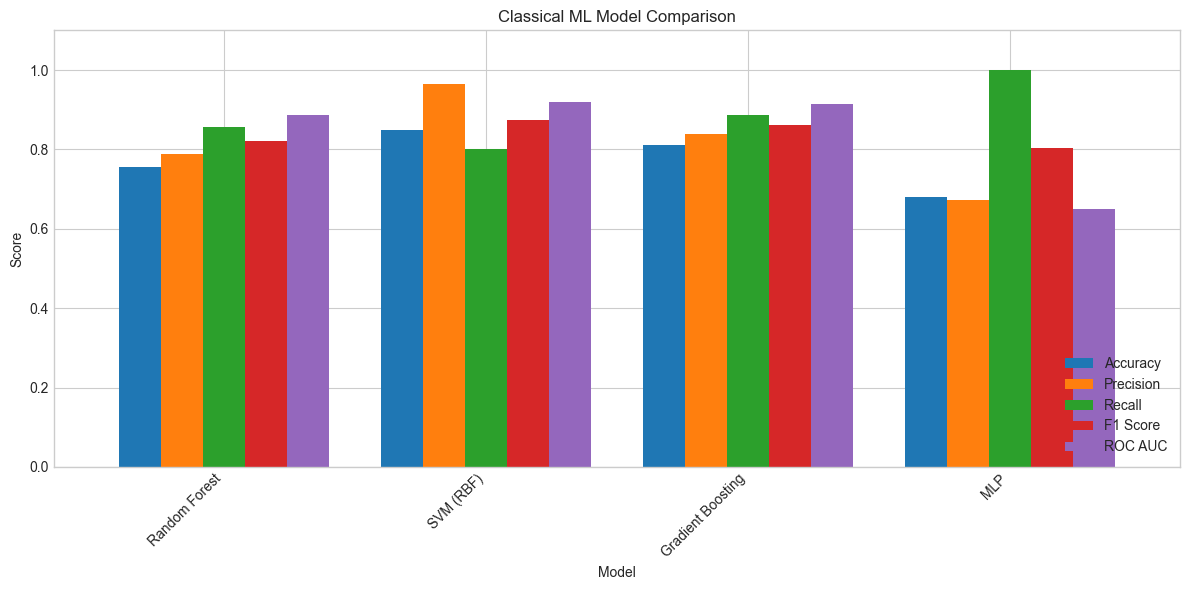

In [9]:
# Compare model performance
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1'],
        'ROC AUC': metrics['roc_auc'] if metrics['roc_auc'] else 0
    }
    for name, metrics in results.items()
}).T

print("\nModel Comparison:")
print(comparison_df.to_string())

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Classical ML Model Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../checkpoints/ml_model_comparison.png', dpi=150)
plt.show()

## 4. Deep Learning Models (CNN)

Now let's train CNN models using PyTorch.

In [10]:
# Create PyTorch data loaders
BATCH_SIZE = 16
NUM_WORKERS = 0  # Set to 0 for Windows compatibility

print("Creating PyTorch data loaders...")
train_loader, val_loader, test_loader = create_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    use_csv=False,  # Use PNG images
    num_workers=NUM_WORKERS
)

# Verify data
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Labels: {labels}")

Creating PyTorch data loaders...
Loaded 264 samples
  Control: 90
  Diabetic: 174

Dataset split:
  Train: 184 samples
  Val: 27 samples
  Test: 53 samples
Loaded 264 samples
  Control: 90
  Diabetic: 174
Loaded 264 samples
  Control: 90
  Diabetic: 174
Loaded 264 samples
  Control: 90
  Diabetic: 174

Batch shape: torch.Size([16, 3, 168, 65])
Labels: tensor([0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0])


C:\Users\Jamel\Documents\Projects\Thesis_DPN\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


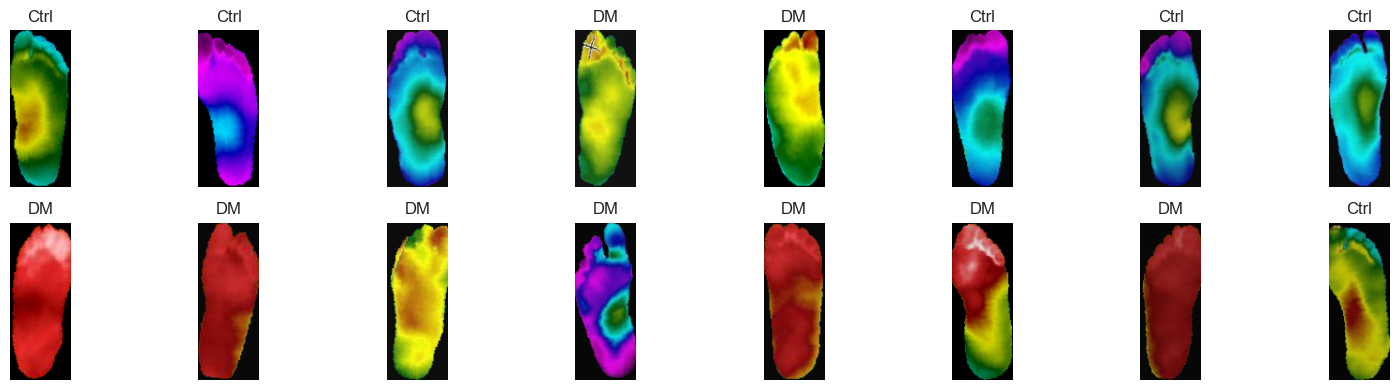

In [11]:
# Visualize a batch
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(min(16, len(images))):
    ax = axes[i // 8, i % 8]
    img = images[i].permute(1, 2, 0).numpy()
    # Denormalize
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    label = 'DM' if labels[i] == 1 else 'Ctrl'
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../checkpoints/training_batch_sample.png', dpi=150)
plt.show()

In [12]:
# Training hyperparameters
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10

# Choose model
MODEL_NAME = 'lightweight_cnn'  # Options: 'cnn', 'lightweight_cnn', 'resnet'

print(f"Using model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_classes=2, input_channels=3)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using model: lightweight_cnn
Total parameters: 41,154
Trainable parameters: 41,154


In [13]:
# Initialize trainer
trainer = CNNTrainer(
    model=model,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"Training device: {trainer.device}")

Training device: cpu


In [14]:
# Train the model
history = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    save_dir=CHECKPOINT_DIR
)

Training on cpu
Training samples: 184
Validation samples: 27
--------------------------------------------------

Epoch 1/50


Training: 100%|██████████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.27it/s, loss=0.4164, acc=66.85%]


Train Loss: 0.5447 | Train Acc: 0.6685
Val Loss: 0.5154 | Val Acc: 0.7407
Saved best model with val_acc: 0.7407

Epoch 2/50


Training: 100%|██████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 18.93it/s, loss=0.6062, acc=73.91%]


Train Loss: 0.4431 | Train Acc: 0.7391
Val Loss: 0.4610 | Val Acc: 0.7037

Epoch 3/50


...

Train Loss: 0.1952 | Train Acc: 0.9239
Val Loss: 0.1816 | Val Acc: 0.9630

Epoch 49/50


Training: 100%|██████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 23.93it/s, loss=0.3837, acc=89.67%]


Train Loss: 0.2133 | Train Acc: 0.8967
Val Loss: 0.1909 | Val Acc: 0.9630

Epoch 50/50


Training: 100%|██████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 22.84it/s, loss=0.3228, acc=90.22%]


Train Loss: 0.2466 | Train Acc: 0.9022
Val Loss: 0.1725 | Val Acc: 0.9259


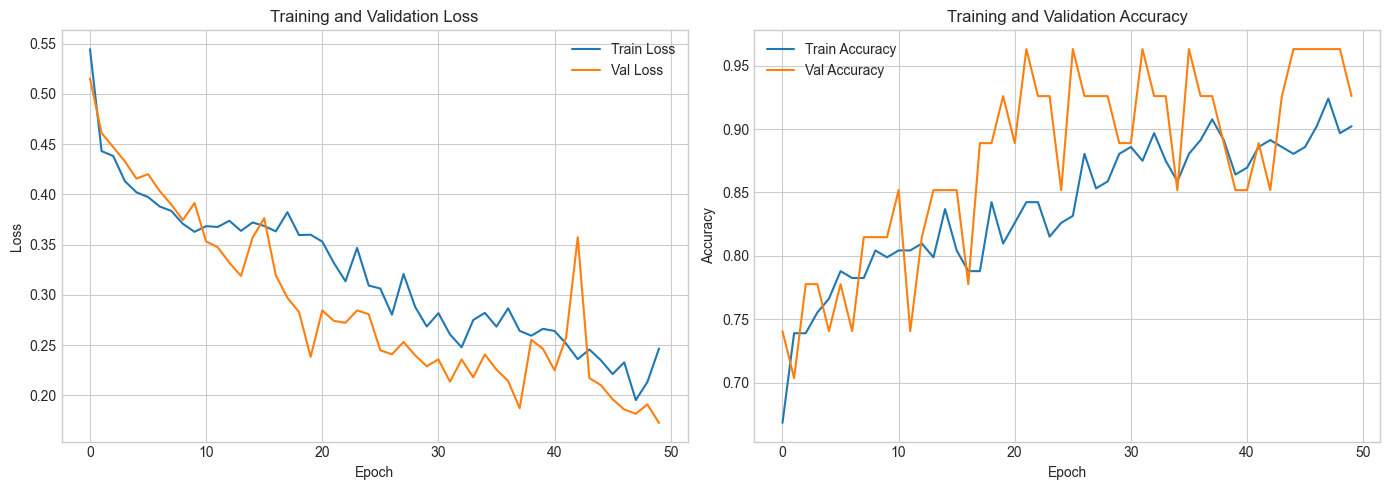

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../checkpoints/training_history.png', dpi=150)
plt.show()

In [16]:
# Load best model and evaluate on test set
trainer.load_checkpoint(f"{CHECKPOINT_DIR}/best_model.pth")

cnn_metrics = trainer.evaluate(test_loader)
print_metrics(cnn_metrics, "CNN Test Results")


CNN Test Results
accuracy: 0.8868
precision: 0.9394
recall: 0.8857
f1: 0.9118
roc_auc: 0.9397

Confusion Matrix:
             Pred Ctrl  Pred DM
   True Ctrl       16        2
     True DM        4       31

              precision    recall  f1-score   support

     Control       0.80      0.89      0.84        18
    Diabetic       0.94      0.89      0.91        35

    accuracy                           0.89        53
   macro avg       0.87      0.89      0.88        53
weighted avg       0.89      0.89      0.89        53



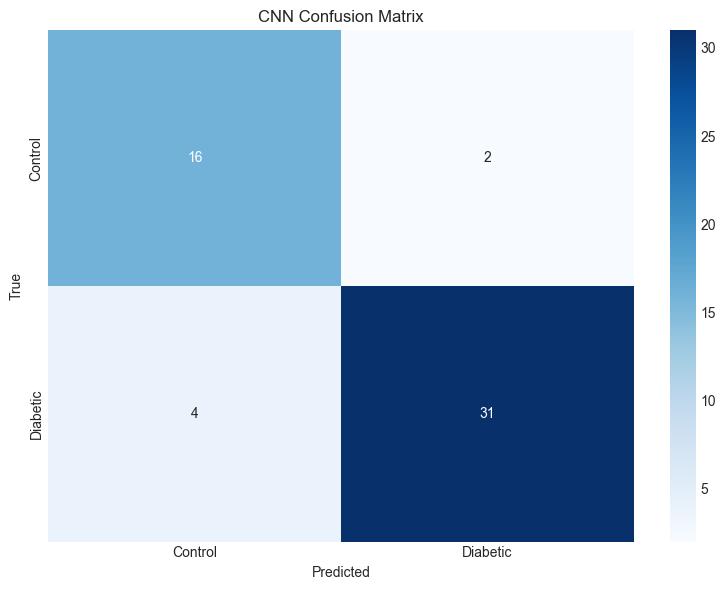

In [17]:
# Plot confusion matrix for CNN
cm = np.array(cnn_metrics['confusion_matrix'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Control', 'Diabetic'],
            yticklabels=['Control', 'Diabetic'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('CNN Confusion Matrix')
plt.tight_layout()
plt.savefig('../checkpoints/cnn_confusion_matrix.png', dpi=150)
plt.show()

## 5. Final Model Comparison

In [18]:
# Add CNN results to comparison
results['CNN'] = cnn_metrics

# Create final comparison
final_comparison = pd.DataFrame({
    name: {
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1'],
        'ROC AUC': metrics['roc_auc'] if metrics['roc_auc'] else 0
    }
    for name, metrics in results.items()
}).T

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(final_comparison.to_string())

# Find best model
best_model = final_comparison['F1 Score'].idxmax()
print(f"\nBest model (by F1 Score): {best_model}")
print(f"F1 Score: {final_comparison.loc[best_model, 'F1 Score']:.4f}")


FINAL MODEL COMPARISON
                   Accuracy  Precision    Recall  F1 Score   ROC AUC
Random Forest      0.754717   0.789474  0.857143  0.821918  0.885714
SVM (RBF)          0.849057   0.965517  0.800000  0.875000  0.919048
Gradient Boosting  0.811321   0.837838  0.885714  0.861111  0.914286
MLP                0.679245   0.673077  1.000000  0.804598  0.649206
CNN                0.886792   0.939394  0.885714  0.911765  0.939683

Best model (by F1 Score): CNN
F1 Score: 0.9118


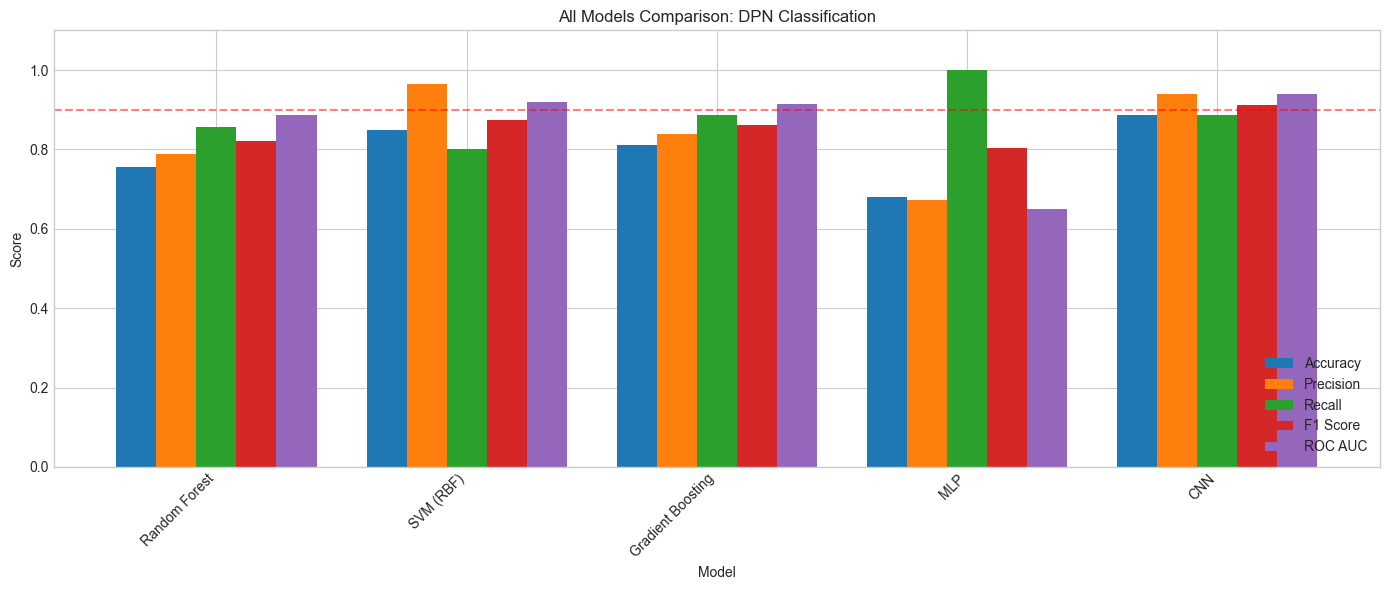

In [19]:
# Final comparison plot
fig, ax = plt.subplots(figsize=(14, 6))
final_comparison.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('All Models Comparison: DPN Classification')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='90% threshold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../checkpoints/final_model_comparison.png', dpi=150)
plt.show()

In [20]:
# Save final comparison to CSV
final_comparison.to_csv('../checkpoints/model_comparison_results.csv')
print("\nResults saved to ../checkpoints/model_comparison_results.csv")
print("Training complete!")


Results saved to ../checkpoints/model_comparison_results.csv
Training complete!


## 6. Save Best Model for Deployment

In [21]:
# Save the best performing model for API deployment
import joblib

# If best model is sklearn-based
if best_model != 'CNN':
    # Retrain the best sklearn model on full training data
    best_sklearn_model = get_model(best_model.lower().replace(' ', '_').replace('(', '').replace(')', ''))
    best_sklearn_model.fit(X_train_processed, y_train)
    
    # Save with joblib
    joblib.dump(best_sklearn_model, '../checkpoints/best_sklearn_model.joblib')
    print(f"Saved best sklearn model: {best_model}")

# CNN is already saved as best_model.pth
print(f"\nBest CNN model saved at: {CHECKPOINT_DIR}/best_model.pth")
print("\nModels ready for deployment!")


Best CNN model saved at: ../checkpoints/best_model.pth

Models ready for deployment!
